In [1]:
!pip install wordcloud

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from wordcloud import WordCloud, STOPWORDS
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


In [2]:
reddit_data=pd.read_csv(r"C:\Users\khush\Downloads\Reddit_Data.csv.zip")
twitter_data=pd.read_csv(r"C:\Users\khush\Downloads\Twitter_Data.csv.zip")

In [3]:
reddit_data

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [4]:
twitter_data

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
...,...,...
162975,why these 456 crores paid neerav modi not reco...,-1.0
162976,dear rss terrorist payal gawar what about modi...,-1.0
162977,did you cover her interaction forum where she ...,0.0
162978,there big project came into india modi dream p...,0.0


In [5]:
reddit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [6]:
twitter_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [7]:
twitter_data.columns=['message','labels']
reddit_data.columns=['message','labels']

In [8]:
data=pd.concat([twitter_data,reddit_data], ignore_index=True)

In [9]:
data

,message,labels
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
...,...,...
200224,jesus,0.0
200225,kya bhai pure saal chutiya banaya modi aur jab...,1.0
200226,downvote karna tha par upvote hogaya,0.0
200227,haha nice,1.0


In [10]:
data.head()

,message,labels
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [11]:
data.tail()

,message,labels
200224,jesus,0.0
200225,kya bhai pure saal chutiya banaya modi aur jab...,1.0
200226,downvote karna tha par upvote hogaya,0.0
200227,haha nice,1.0
200228,facebook itself now working bjp’ cell,0.0


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200229 entries, 0 to 200228
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   message  200125 non-null  object 
 1   labels   200222 non-null  float64
dtypes: float64(1), object(1)
memory usage: 3.1+ MB


In [13]:
data.isnull().sum()

message    104
labels       7
dtype: int64

In [14]:
data.dropna()

,message,labels
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
...,...,...
200224,jesus,0.0
200225,kya bhai pure saal chutiya banaya modi aur jab...,1.0
200226,downvote karna tha par upvote hogaya,0.0
200227,haha nice,1.0


In [15]:
data['labels'].head()

0   -1.0
1    0.0
2    1.0
3    1.0
4    1.0
Name: labels, dtype: float64

In [16]:
data.head()

,message,labels
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [17]:

data.tail()

,message,labels
200224,jesus,0.0
200225,kya bhai pure saal chutiya banaya modi aur jab...,1.0
200226,downvote karna tha par upvote hogaya,0.0
200227,haha nice,1.0
200228,facebook itself now working bjp’ cell,0.0


In [18]:
data['labels'].isnull().sum()

np.int64(7)

In [19]:
!pip install tensorflow

In [20]:
import re,string,nltk
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import PorterStemmer,WordNetLemmatizer

In [21]:
custom_stopwords = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd",
    'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers',
    'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which',
    'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been',
    'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if',
    'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between',
    'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out',
    'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why',
    'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not',
    'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 'should',
    "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't",
    'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't",
    'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't",
    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}

# पुराना remove_stopwords फ़ंक्शन हटाकर इसे रन करें
def remove_stopwords(text):
    text = ' '.join([word for word in text.split() if word not in custom_stopwords])
    return text

In [22]:
def replace_url(text):
    return re.sub("http?:\/\/\/S*|www\.\S+",'URL',text)

In [23]:
def remove_html(text):
    return re.sub('<.*?>','',text)
    

In [24]:
def replace_mentions(text):
    return re.sub('r@\S*','User',text)
    

In [25]:
def replace_num(text):
    return re.sub('r[+-]?\d{1,3}[- ]?\d{1,10}|\d+(?:\.\d+)?','NUMBER',text)

In [26]:
def replace_heart(text):
    return re.sub(r'❤️|<3','Heart',text)

In [27]:
def remove_alphanumeric(text):
    return re.sub('\w*\d+\w*','',text)

In [28]:
def remove_punctuations(text):
    text=''.join([word for word in text if word not in string.punctuation])
    return text

In [29]:
def lemmatization(text):
    lm= WordNetLemmatizer()
    text = ' '.join([lm.lemmatize(word, pos='v') for word in text.split()])
    return text

In [30]:
def clean_text(text):
    text=str(text).lower()
    text = replace_url(text)
    text = remove_html(text)
    text = replace_mentions(text)
    text = replace_num(text)
    text = replace_heart(text)
    text = remove_alphanumeric(text)
    text = remove_stopwords(text)
    text=remove_punctuations(text)
    #text=stemming(text)
    text=lemmatization(text)
    return text

In [31]:
import nltk
nltk.download("wordnet")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\khush\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [32]:
data['message1']=data['message'].apply(clean_text)

In [33]:
data['message1']

0         modi promise “minimum government maximum gover...
1                    talk nonsense continue drama vote modi
2         say vote modi welcome bjp tell rahul main camp...
3         ask supporters prefix chowkidar name modi grea...
4         answer among powerful world leader today trump...
                                ...                        
200224                                                jesus
200225    kya bhai pure saal chutiya banaya modi aur jab...
200226                 downvote karna tha par upvote hogaya
200227                                            haha nice
200228                              facebook work bjp’ cell
Name: message1, Length: 200229, dtype: object

In [34]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\khush\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [35]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize the VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_sentiment_scores(text):
    # Get sentiment scores using VADER
    scores = sid.polarity_scores(text)
    # Extract compound score, which represents overall sentiment
    compound_score = scores['compound']
    # Return compound score
    return compound_score

# Apply sentiment analysis to the cleaned text data
data['sentiment_score'] = data['message1'].apply(get_sentiment_scores)


In [36]:
data.head()

,message,labels,message1,sentiment_score
0,when modi promised “minimum government maximum...,-1.0,modi promise “minimum government maximum gover...,0.4939
1,talk all the nonsense and continue all the dra...,0.0,talk nonsense continue drama vote modi,-0.4019
2,what did just say vote for modi welcome bjp t...,1.0,say vote modi welcome bjp tell rahul main camp...,0.7096
3,asking his supporters prefix chowkidar their n...,1.0,ask supporters prefix chowkidar name modi grea...,0.4939
4,answer who among these the most powerful world...,1.0,answer among powerful world leader today trump...,0.4215


In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200229 entries, 0 to 200228
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   message          200125 non-null  object 
 1   labels           200222 non-null  float64
 2   message1         200229 non-null  object 
 3   sentiment_score  200229 non-null  float64
dtypes: float64(2), object(2)
memory usage: 6.1+ MB


In [38]:
data.drop("message",axis=1,inplace=True)

In [39]:
data.head()

,labels,message1,sentiment_score
0,-1.0,modi promise “minimum government maximum gover...,0.4939
1,0.0,talk nonsense continue drama vote modi,-0.4019
2,1.0,say vote modi welcome bjp tell rahul main camp...,0.7096
3,1.0,ask supporters prefix chowkidar name modi grea...,0.4939
4,1.0,answer among powerful world leader today trump...,0.4215


<Axes: xlabel='labels'>

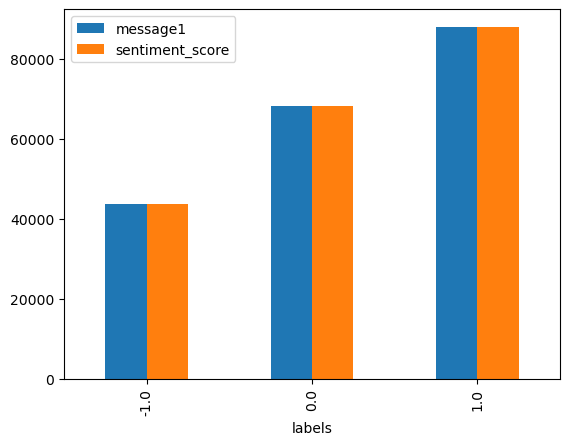

In [40]:
data.groupby('labels').count().plot(kind='bar')

In [41]:
print(data.head())

   labels                                           message1  sentiment_score
0    -1.0  modi promise “minimum government maximum gover...           0.4939
1     0.0             talk nonsense continue drama vote modi          -0.4019
2     1.0  say vote modi welcome bjp tell rahul main camp...           0.7096
3     1.0  ask supporters prefix chowkidar name modi grea...           0.4939
4     1.0  answer among powerful world leader today trump...           0.4215


In [42]:
data['labels']

0        -1.0
1         0.0
2         1.0
3         1.0
4         1.0
         ... 
200224    0.0
200225    1.0
200226    0.0
200227    1.0
200228    0.0
Name: labels, Length: 200229, dtype: float64

In [43]:
data['label']=data['labels'].map({-1.0:'Negative', 0.0:'Neutral', 1.0:'Positive'})

In [44]:
import plotly.express as px
counts = data['label'].value_counts().reset_index()
fig = px.pie(counts,values='count',names='label', title='Pie chart of different sentiments of data')
fig.show()

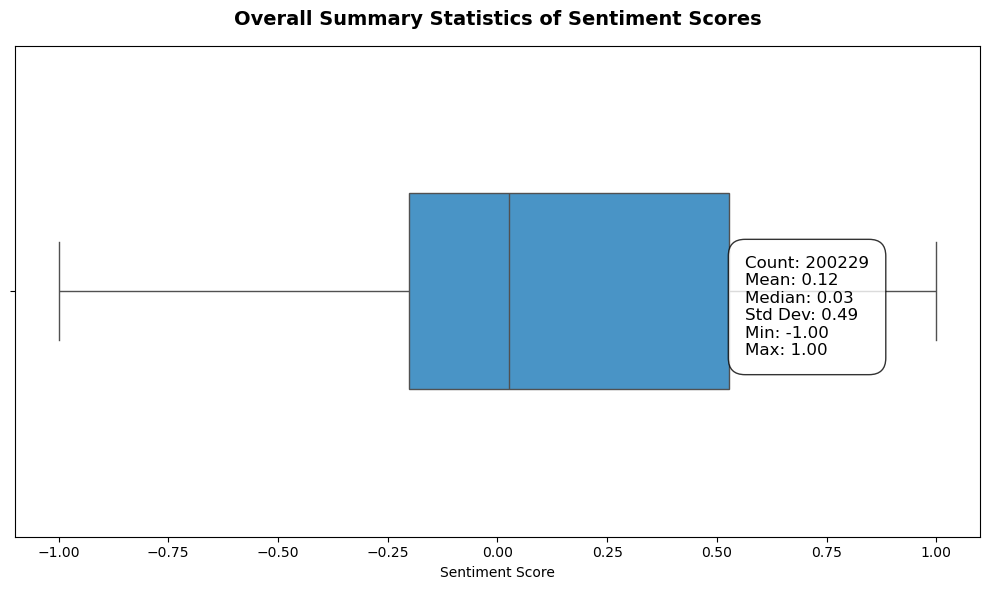

In [45]:
count_val = data['sentiment_score'].count()
mean_val = data['sentiment_score'].mean()
median_val = data['sentiment_score'].median()
std_val = data['sentiment_score'].std()
min_val = data['sentiment_score'].min()
max_val = data['sentiment_score'].max()

# 2. Plotting (Box Plot data ka spread dikhane ke liye sabse best hai)
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['sentiment_score'], color='#3498db', width=0.4)
# 3. Graph ke upar saari details ka box lagayein
info_text = (
    f"Count: {count_val}\n"
    f"Mean: {mean_val:.2f}\n"
    f"Median: {median_val:.2f}\n"
    f"Std Dev: {std_val:.2f}\n"
    f"Min: {min_val:.2f}\n"
    f"Max: {max_val:.2f}"
)

# Yeh code graph ke side mein text box bana dega
plt.gcf().text(0.75, 0.4, info_text, fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=1'))

plt.title('Overall Summary Statistics of Sentiment Scores', fontsize=14, weight='bold', pad=15)
plt.xlabel('Sentiment Score')
plt.tight_layout()
plt.show()

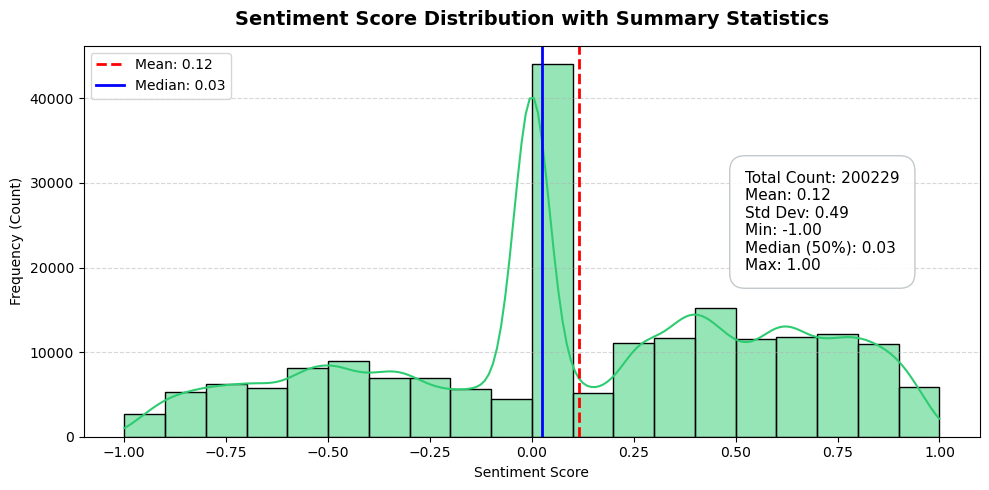

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Saari statistical values nikal lijiye
stats = data['sentiment_score'].describe()

# 2. Graph ka size aur layout set karein
fig, ax = plt.subplots(figsize=(10, 5))

# 3. Histogram aur Density Plot banayein (Jo data ka flow dikhayega)
sns.histplot(data['sentiment_score'], kde=True, color='#2ecc71', ax=ax, bins=20)

# Mean aur Median ki vertical lines graph par draw karein
plt.axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {stats['mean']:.2f}")
plt.axvline(stats['50%'], color='blue', linestyle='-', linewidth=2, label=f"Median: {stats['50%']:.2f}")

# 4. Ek clean box ke andar .describe() ki saari details likhein
info_text = (
    f"Total Count: {int(stats['count'])}\n"
    f"Mean: {stats['mean']:.2f}\n"
    f"Std Dev: {stats['std']:.2f}\n"
    f"Min: {stats['min']:.2f}\n"
    f"Median (50%): {stats['50%']:.2f}\n"
    f"Max: {stats['max']:.2f}"
)

# Is text box ko graph ke right side par set karein
plt.gcf().text(0.75, 0.45, info_text, fontsize=11, 
               bbox=dict(facecolor='white', alpha=0.9, edgecolor='#bdc3c7', boxstyle='round,pad=1'))

# 5. Title aur Labels lgaayein
plt.title('Sentiment Score Distribution with Summary Statistics', fontsize=14, weight='bold', pad=15)
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency (Count)')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



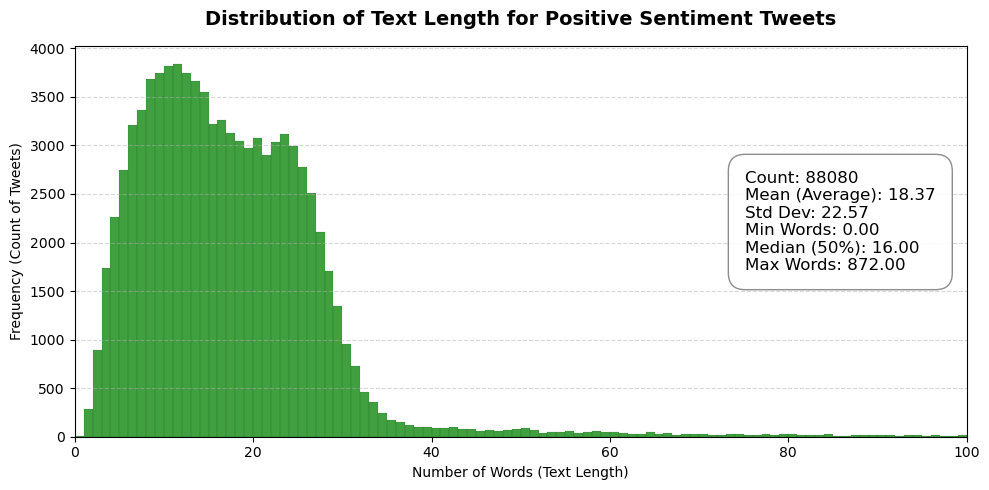

In [47]:
positive_data = data[data['label'] == 'Positive']
positive_lengths = positive_data['message1'].str.split().apply(len)

# 2. Positive data ki saari statistical details (.describe) nikaal lijiye
stats = positive_lengths.describe()

# 3. Ek simple graph paper taiyar karein
plt.figure(figsize=(10, 5))

# 4. Green color ka histplot banayein jo data ka flow dikhaye
sns.histplot(positive_lengths, color='green', binwidth=1, kde=False)
plt.xlim(0, 100) 

# 5. Ek simple text box banayein jisme saari details saaf-saaf likhi hon
# (Isme koi complex table code nahi hai, yeh asani se readable hai)
info_text = (
    f"Count: {int(stats['count'])}\n"
    f"Mean (Average): {stats['mean']:.2f}\n"
    f"Std Dev: {stats['std']:.2f}\n"
    f"Min Words: {stats['min']:.2f}\n"
    f"Median (50%): {stats['50%']:.2f}\n"
    f"Max Words: {stats['max']:.2f}"
)

# Is text box ko graph ke right side par set kar dijiye
plt.gcf().text(0.75, 0.45, info_text, fontsize=12, 
               bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=1'))

# 6. Title aur axis ke naam likhein (Ekdum simple)
plt.title('Distribution of Text Length for Positive Sentiment Tweets', fontsize=14, weight='bold', pad=15)
plt.xlabel('Number of Words (Text Length)')
plt.ylabel('Frequency (Count of Tweets)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 7. Final graph screen par show karein
plt.tight_layout()
plt.show()

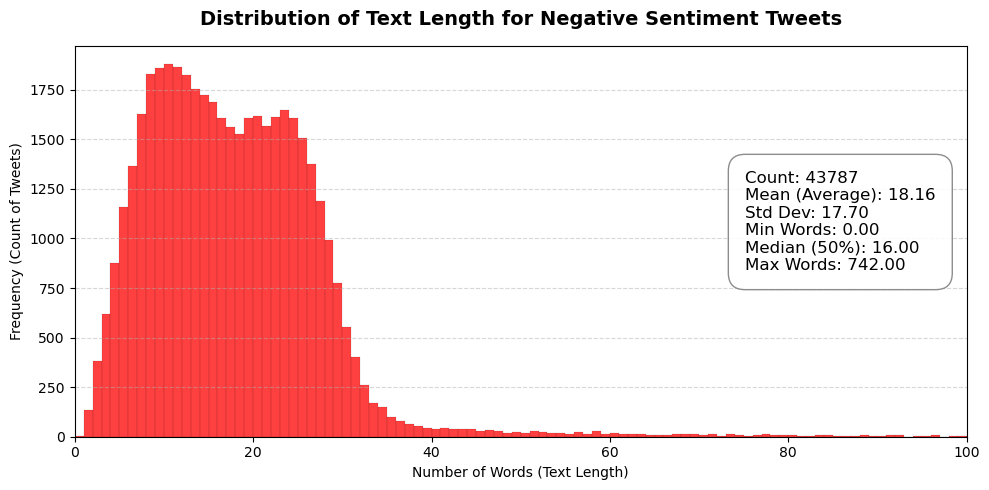

In [48]:


# 1. Filter data for Negative label and calculate text lengths
negative_data = data[data['label'] == 'Negative']
negative_lengths = negative_data['message1'].str.split().apply(len)

# 2. Get all statistical details using .describe()
stats_neg = negative_lengths.describe()

# 3. Initialize the plot figure size
plt.figure(figsize=(10, 5))

# 4. Create a red histplot to show the distribution of data
sns.histplot(negative_lengths, color='red', binwidth=1, kde=False)
plt.xlim(0, 100) 

# 5. Create a simple text box containing all statistical details
info_text_neg = (
    f"Count: {int(stats_neg['count'])}\n"
    f"Mean (Average): {stats_neg['mean']:.2f}\n"
    f"Std Dev: {stats_neg['std']:.2f}\n"
    f"Min Words: {stats_neg['min']:.2f}\n"
    f"Median (50%): {stats_neg['50%']:.2f}\n"
    f"Max Words: {stats_neg['max']:.2f}"
)

# Position the text box on the right side of the graph
plt.gcf().text(0.75, 0.45, info_text_neg, fontsize=12, 
               bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=1'))

# 6. Set the title and axis labels
plt.title('Distribution of Text Length for Negative Sentiment Tweets', fontsize=14, weight='bold', pad=15)
plt.xlabel('Number of Words (Text Length)')
plt.ylabel('Frequency (Count of Tweets)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 7. Adjust layout and display the final graph
plt.tight_layout()
plt.show()



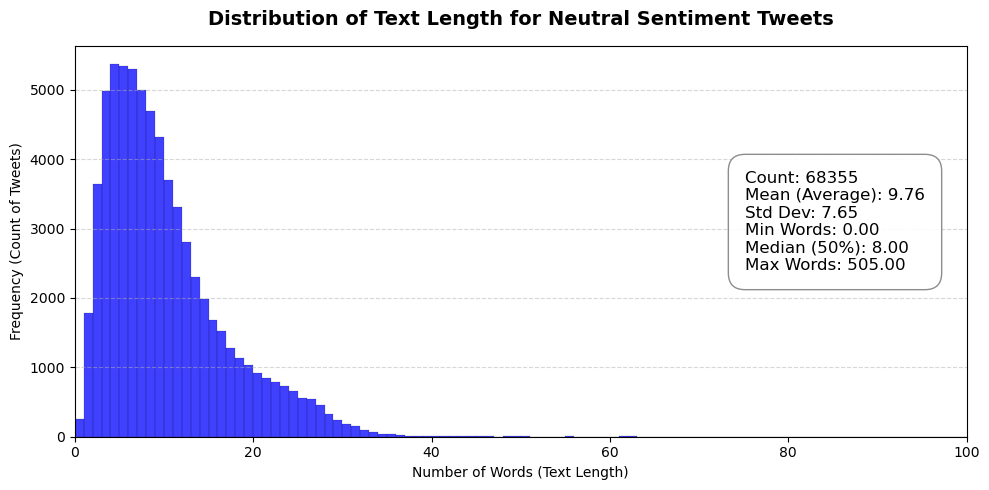

In [49]:

# 1. Filter data for Neutral label and calculate text lengths
neutral_data = data[data['label'] == 'Neutral']
neutral_lengths = neutral_data['message1'].str.split().apply(len)

# 2. Get all statistical details using .describe()
stats_neu = neutral_lengths.describe()

# 3. Initialize the plot figure size
plt.figure(figsize=(10, 5))

# 4. Create a blue histplot to show the distribution of data
sns.histplot(neutral_lengths, color='blue', binwidth=1, kde=False)
plt.xlim(0, 100) 

# 5. Create a simple text box containing all statistical details
info_text_neu = (
    f"Count: {int(stats_neu['count'])}\n"
    f"Mean (Average): {stats_neu['mean']:.2f}\n"
    f"Std Dev: {stats_neu['std']:.2f}\n"
    f"Min Words: {stats_neu['min']:.2f}\n"
    f"Median (50%): {stats_neu['50%']:.2f}\n"
    f"Max Words: {stats_neu['max']:.2f}"
)

# Position the text box on the right side of the graph
plt.gcf().text(0.75, 0.45, info_text_neu, fontsize=12, 
               bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=1'))

# 6. Set the title and axis labels
plt.title('Distribution of Text Length for Neutral Sentiment Tweets', fontsize=14, weight='bold', pad=15)
plt.xlabel('Number of Words (Text Length)')
plt.ylabel('Frequency (Count of Tweets)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 7. Adjust layout and display the final graph
plt.tight_layout()
plt.show()


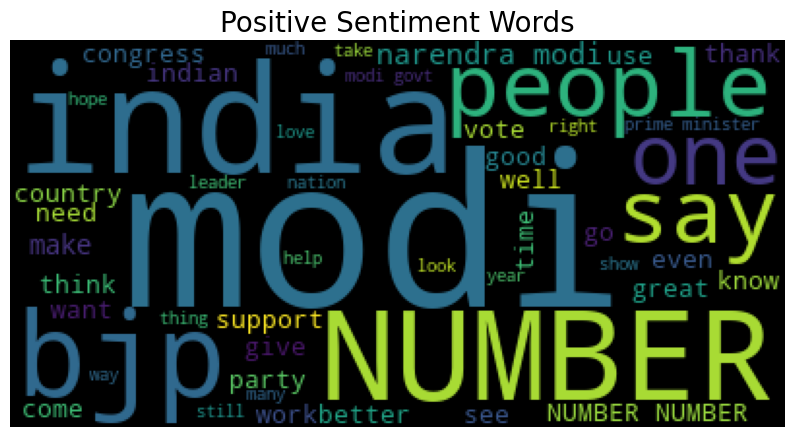

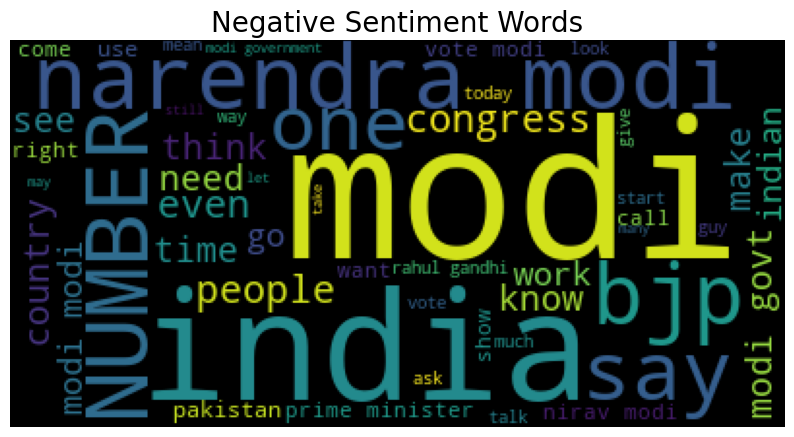

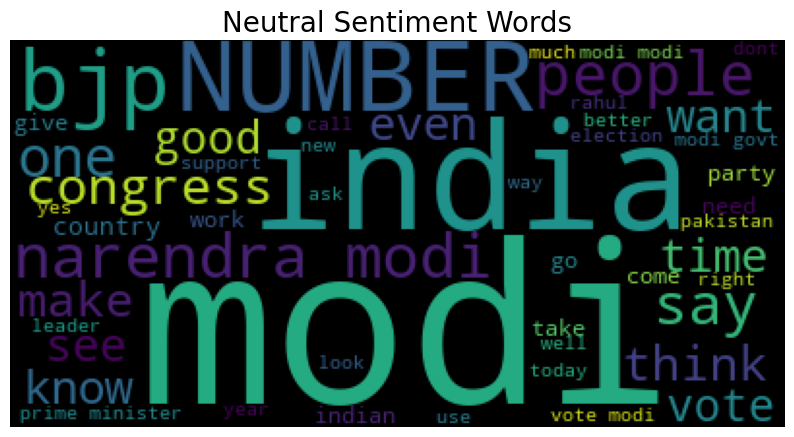

In [50]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

def wordcount_gen(category, sentiment_column='sentiment_score'):
    """
    We created a function named 'wordcount_gen' to generate a Word Cloud.
    It takes the 'category' (Positive/Negative/Neutral) as input and directly 
    filters our 'data' DataFrame without using any temporary 'df' variables.
    """
    
    # Filter the 'data' variable directly based on the sentiment category
    if category == 'Positive':
        filtered_data = data[data[sentiment_column] > 0.6]
    elif category == 'Negative':
        filtered_data = data[data[sentiment_column] < 0.4]
    else: 
        filtered_data = data[(data[sentiment_column] >= 0.4) & (data[sentiment_column] <= 0.6)]

    # Combine all text messages from the filtered data into a single string
    combined_tweets = " ".join(filtered_data['message1'].astype(str))
    
    # Initialize the WordCloud configuration with a black background and a 50-word limit
    wc = WordCloud(background_color='black', max_words=50, stopwords=STOPWORDS)

    # Generate and display the word cloud plot
    plt.figure(figsize=(10, 10))
    plt.imshow(wc.generate(combined_tweets))
    plt.title(f'{category} Sentiment Words', fontsize=20)
    plt.axis('off')
    plt.show()

# Run the function for each category
wordcount_gen('Positive')
wordcount_gen('Negative')
wordcount_gen('Neutral')


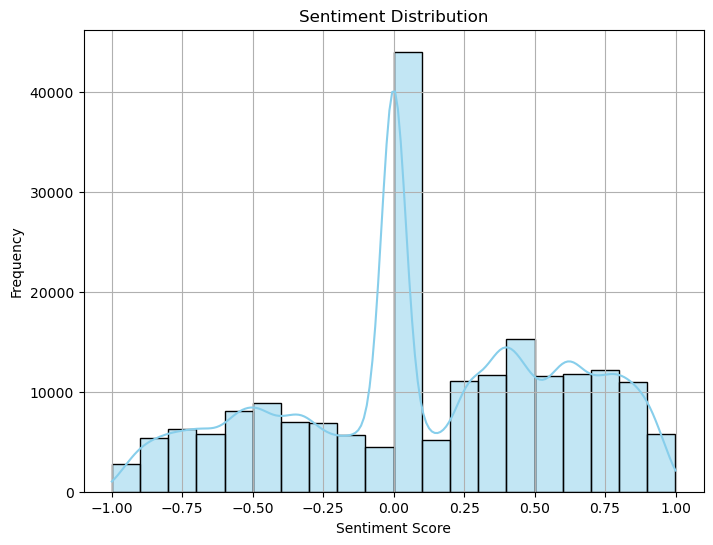

In [51]:
plt.figure(figsize=(8, 6))
sns.histplot(data['sentiment_score'], bins=20, kde=True, color='skyblue')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


C:\Users\khush\AppData\Local\Temp\ipykernel_23040\1589436855.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




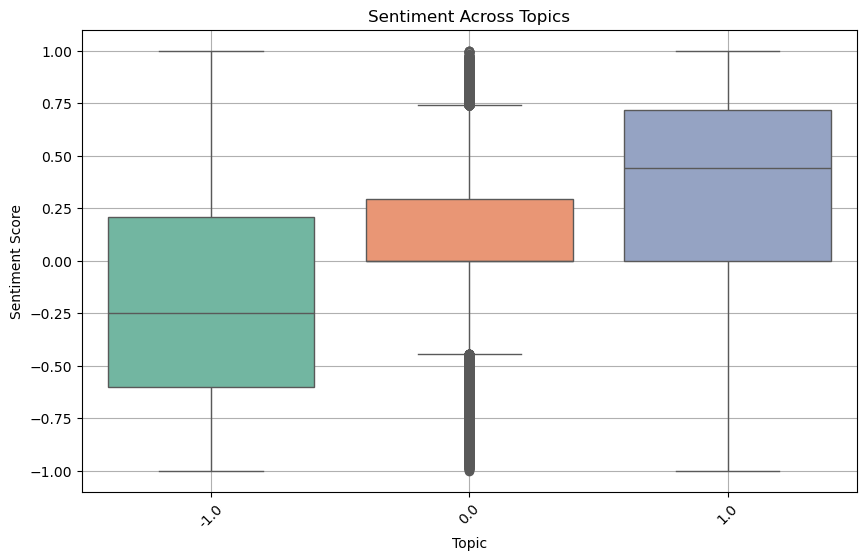

In [52]:
# Compare sentiment across labels 
plt.figure(figsize=(10, 6))
sns.boxplot(x='labels', y='sentiment_score', data=data, palette='Set2')
plt.title('Sentiment Across Topics')
plt.xlabel('Topic')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

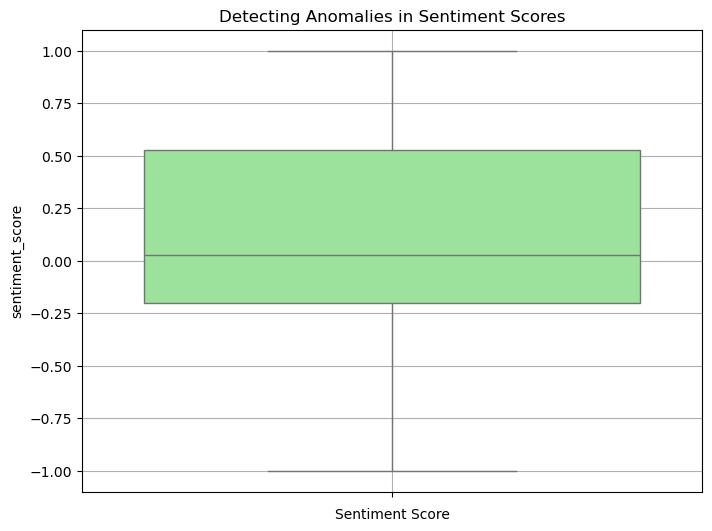

In [53]:
# Detect anomalies or outliers in sentiment scores
plt.figure(figsize=(8, 6))
sns.boxplot(data['sentiment_score'], color='lightgreen')
plt.title('Detecting Anomalies in Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.grid(True)
plt.show()

C:\Users\khush\AppData\Local\Temp\ipykernel_23040\2541151485.py:9: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



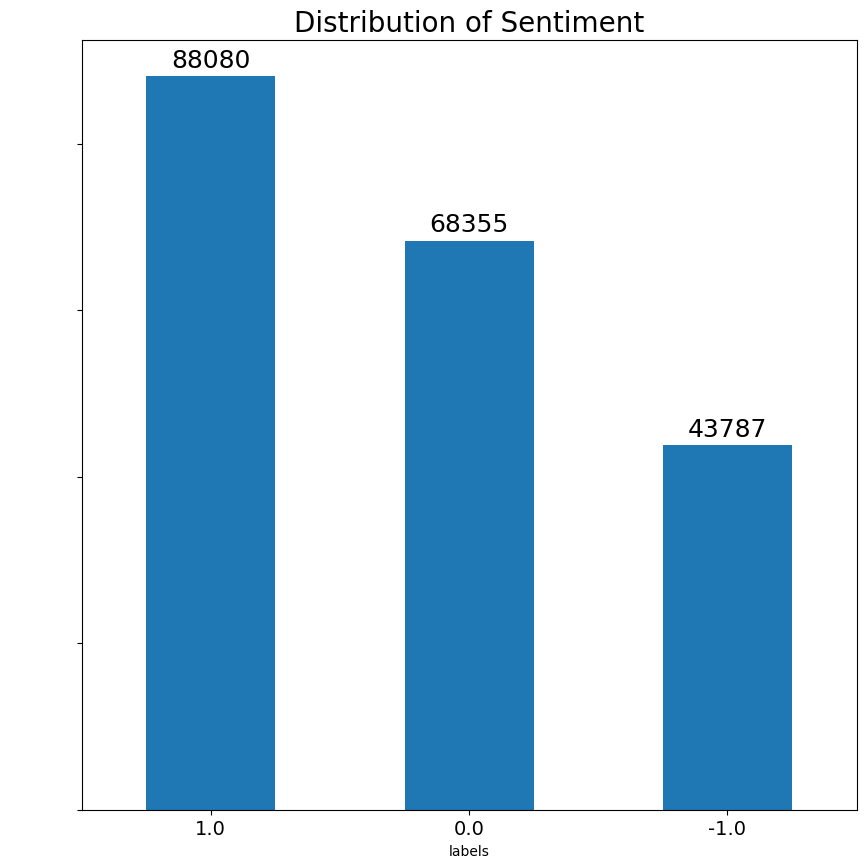

In [54]:
fig, ax = plt.subplots(figsize=(10, 10))
data['labels'].value_counts().plot(kind='bar', ax=ax)

# 2. Typography aur Title set karein
plt.title('Distribution of Sentiment', size=20)
plt.xticks(rotation=0, size=14)
plt.yticks(size=14, color='white')
ax.bar_label(ax.containers[0], padding=3, size=18) 
fig.show()

# Train & Test Split

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200229 entries, 0 to 200228
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   labels           200222 non-null  float64
 1   message1         200229 non-null  object 
 2   sentiment_score  200229 non-null  float64
 3   label            200222 non-null  object 
dtypes: float64(2), object(2)
memory usage: 6.1+ MB


In [57]:
data['label'].isnull().sum()

np.int64(7)

In [58]:
data = data.dropna(subset=['label'])

In [59]:
data.isnull().sum()

labels             0
message1           0
sentiment_score    0
label              0
dtype: int64

In [60]:
#Finding X and y
X = data['message1']
y = data['label']


In [61]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


In [62]:
##Vectorize text data
# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf=  tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf= tfidf_vectorizer.transform(X_test)


In [63]:
!pip install xgboost lightgbm

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC  
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier # Added AdaBoostClassifier here
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import MultinomialNB  
from sklearn.preprocessing import LabelEncoder # Added to convert text labels to numbers
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Convert text labels to numbers (0, 1, 2) so XGBoost does not throw an error
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Class names ('Negative', 'Neutral', 'Positive') will be automatically stored here
class_names = label_encoder.classes_

classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "LinearSVC": LinearSVC(max_iter=2000), 
    "MultinomialNB": MultinomialNB(),       
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "LGBMClassifier": LGBMClassifier(n_jobs=-1), 
    "XGBClassifier": XGBClassifier(n_jobs=-1), 
    "AdaBoostClassifier": AdaBoostClassifier(), # Added to the dictionary
    "RandomForestClassifier": RandomForestClassifier(n_jobs=-1),
}

# Loop through each classifier
for name, classifier in classifiers.items():
    print(f"Training {name}...") # Shows which model is currently running
    
    # 2. Use y_train_encoded instead of raw text y_train
    classifier.fit(X_train_tfidf, y_train_encoded)
    
    # 3. Use y_test_encoded instead of raw text y_test
    y_pred = classifier.predict(X_test_tfidf)
    
    # Calculate accuracy score
    accuracy = accuracy_score(y_test_encoded, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")
    
    # Generate normalized confusion matrix (values in percentages from 0 to 1)
    conf_matrix_norm = confusion_matrix(y_test_encoded, y_pred, normalize='true')
    
    plt.figure(figsize=(5, 4))
    # Passing class_names displays 'Negative', 'Neutral', 'Positive' on the graph axes
    sns.heatmap(conf_matrix_norm, annot=True, fmt=".2f", cmap="Blues", 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show() # Display the confusion matrix heatmap plot
    
    # Generate and display classification report with original class names
    report = classification_report(y_test_encoded, y_pred, target_names=class_names)
    print(f"{name} Classification Report:\n{report}")
    print("-" * 50)


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize MLPClassifier model
mlp_model = MLPClassifier()

# Train the MLPClassifier model on the training data
mlp_model.fit(X_train_tfidf, y_train)


In [ ]:
# Predict on the testing data
y_pred_mlp = mlp_model.predict(X_test_tfidf)

# Calculate accuracy
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print("MLPClassifier Accuracy:", accuracy_mlp)

In [ ]:
# Generate confusion matrix
conf_matrix_mlp = confusion_matrix(y_test, y_pred_mlp)
print("MLPClassifier Confusion Matrix:")
print(conf_matrix_mlp)

# Generate classification report
report_mlp = classification_report(y_test, y_pred_mlp)
print("MLPClassifier Classification Report:")
print(report_mlp)